# Session 3 — Subplots, Layouts & Annotations

Runnable code from the **Build It**, **Experiment**, and **Mini Project** sections.
Run each cell top to bottom.

## 1. Build It — Core Code

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(3)

### 3.1 Subplot grids with `plt.subplots()`

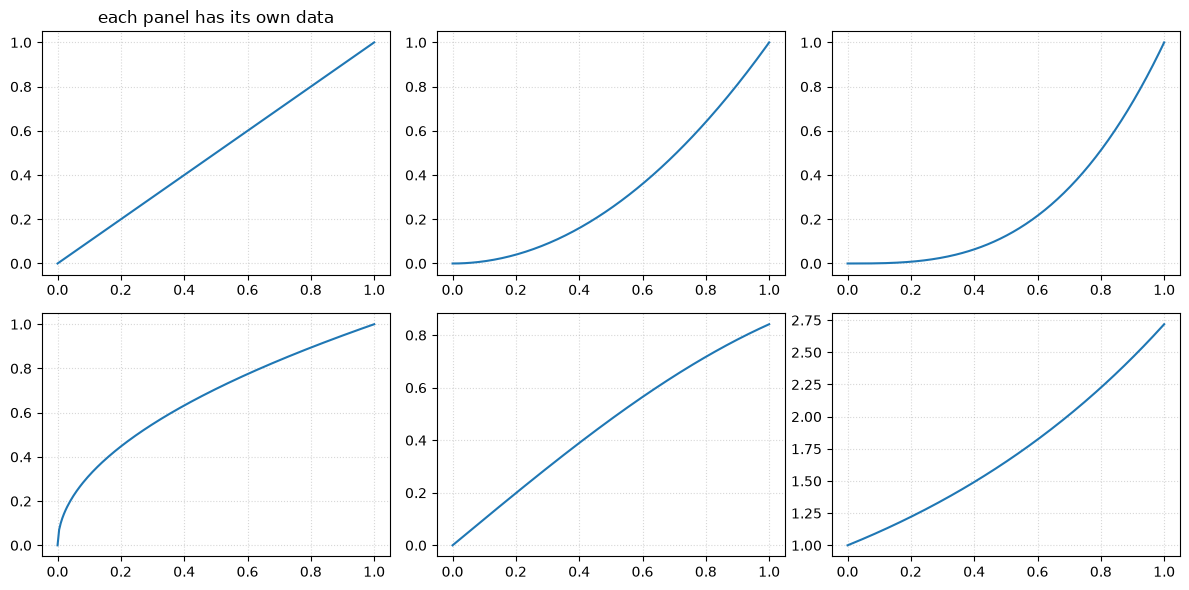

In [2]:
x = np.linspace(0, 1, 200)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))
functions = [x, x ** 2, x ** 3, np.sqrt(x), np.sin(x), np.exp(x)]

for ax, f in zip(axes.ravel(), functions):
    ax.plot(x, f, color="tab:blue")
    ax.grid(True, linestyle=":", alpha=0.5)

axes[0, 0].set_title("each panel has its own data")
fig.tight_layout()
plt.show()

### 3.2 Sharing axes with `sharex` / `sharey`

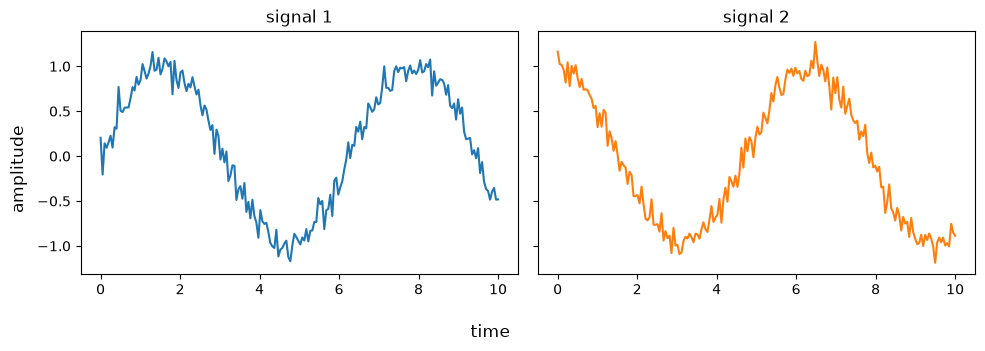

In [3]:
t = np.linspace(0, 10, 200)
signal1 = np.sin(t) + rng.normal(scale=0.1, size=t.size)
signal2 = np.cos(t) + rng.normal(scale=0.1, size=t.size)

fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 3.5))
axes[0].plot(t, signal1, color="tab:blue")
axes[1].plot(t, signal2, color="tab:orange")
axes[0].set_title("signal 1")
axes[1].set_title("signal 2")
fig.supxlabel("time")
fig.supylabel("amplitude")
fig.tight_layout()
plt.show()

### 3.3 Layout control: constrained layout

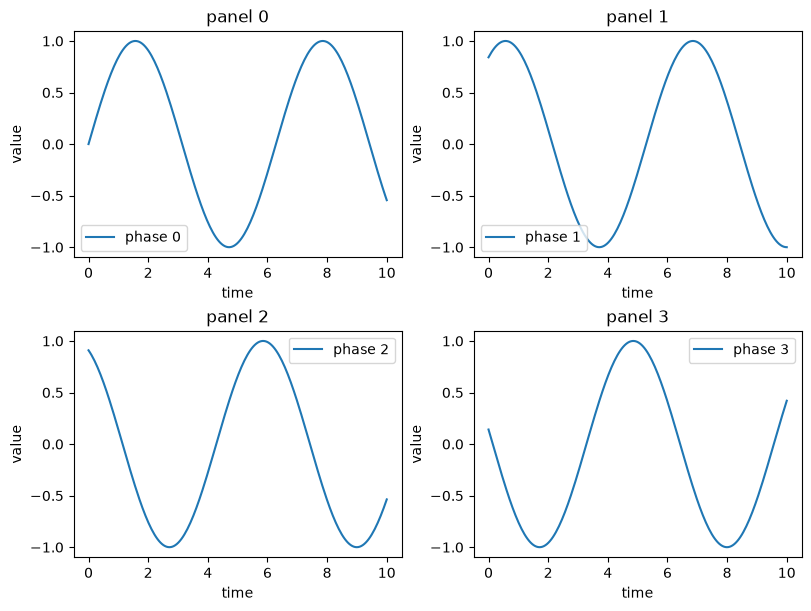

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6), layout="constrained")
for i, ax in enumerate(axes.ravel()):
    ax.plot(t, np.sin(t + i), label=f"phase {i}")
    ax.set_title(f"panel {i}")
    ax.set_xlabel("time")
    ax.set_ylabel("value")
    ax.legend()
plt.show()

### 3.4 Custom layouts with `GridSpec`

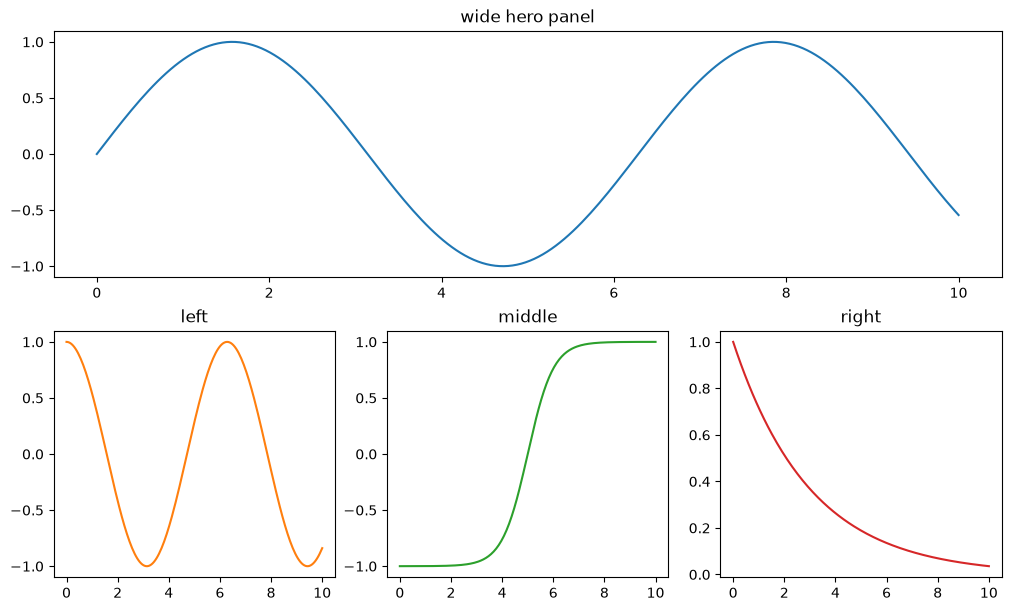

In [5]:
fig = plt.figure(figsize=(10, 6), layout="constrained")
gs = fig.add_gridspec(2, 3)

ax_top = fig.add_subplot(gs[0, :])      # top row spans all 3 columns
ax_left = fig.add_subplot(gs[1, 0])
ax_mid = fig.add_subplot(gs[1, 1])
ax_right = fig.add_subplot(gs[1, 2])

ax_top.plot(t, np.sin(t), color="tab:blue")
ax_top.set_title("wide hero panel")
ax_left.plot(t, np.cos(t), color="tab:orange")
ax_left.set_title("left")
ax_mid.plot(t, np.tanh(t - 5), color="tab:green")
ax_mid.set_title("middle")
ax_right.plot(t, np.exp(-t / 3), color="tab:red")
ax_right.set_title("right")
plt.show()

### 3.5 A second y-axis with `twinx()`

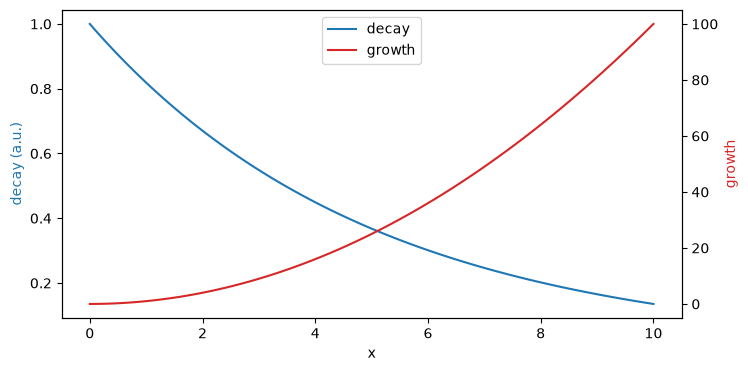

In [6]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

x = np.linspace(0, 10, 100)
line1, = ax1.plot(x, np.exp(-x / 5), color="tab:blue", label="decay")
ax1.set_xlabel("x")
ax1.set_ylabel("decay (a.u.)", color="tab:blue")

line2, = ax2.plot(x, x ** 2, color="tab:red", label="growth")
ax2.set_ylabel("growth", color="tab:red")

ax1.legend(handles=[line1, line2], loc="upper center")
plt.show()

### 3.6 Annotations: `text`, `annotate`, and arrows

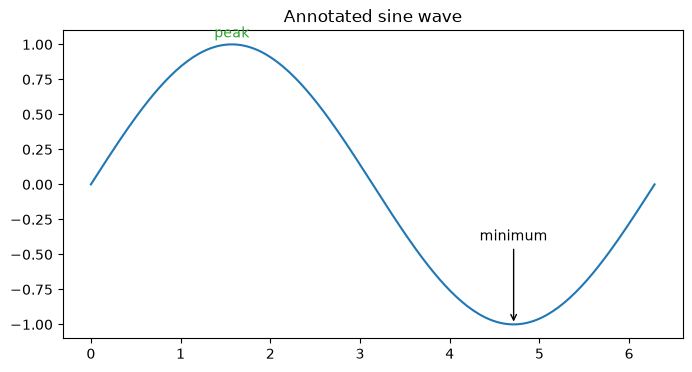

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
xs = np.linspace(0, 2 * np.pi, 200)
ax.plot(xs, np.sin(xs), color="tab:blue")

ax.text(np.pi / 2, 1.05, "peak", ha="center", color="tab:green")
ax.annotate(
    "minimum",
    xy=(1.5 * np.pi, -1.0),
    xytext=(1.5 * np.pi, -0.4),
    ha="center",
    arrowprops=dict(arrowstyle="->", color="black"),
)
ax.set_title("Annotated sine wave")
plt.show()

### 3.7 Reference lines and shaded regions

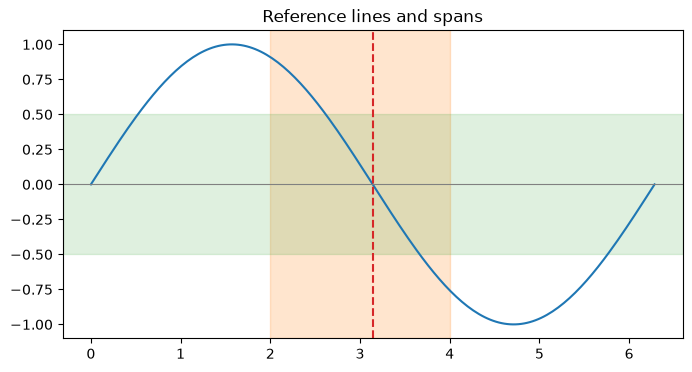

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xs, np.sin(xs), color="tab:blue")

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(np.pi, color="tab:red", linestyle="--")
ax.axvspan(2, 4, color="tab:orange", alpha=0.2)
ax.axhspan(-0.5, 0.5, color="tab:green", alpha=0.15)
ax.set_title("Reference lines and spans")
plt.show()

## 2. Experiment

Predict the result *before* running each cell.

**Experiment 1:** what does `sharex=True` do to the tick labels?

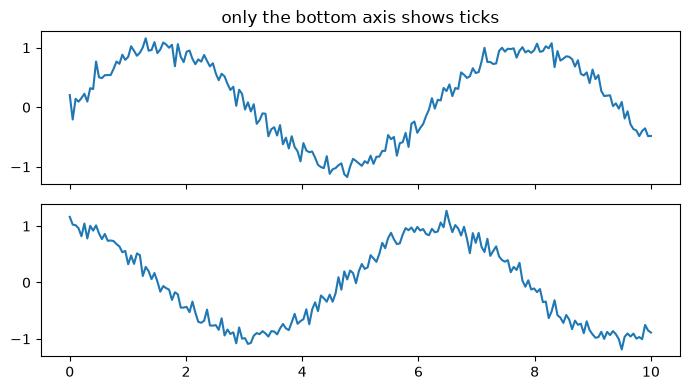

In [9]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(7, 4))
axes[0].plot(t, signal1)
axes[1].plot(t, signal2)
axes[0].set_title("only the bottom axis shows ticks")
fig.tight_layout()
plt.show()

**Experiment 2:** change the height ratio of a `GridSpec`.

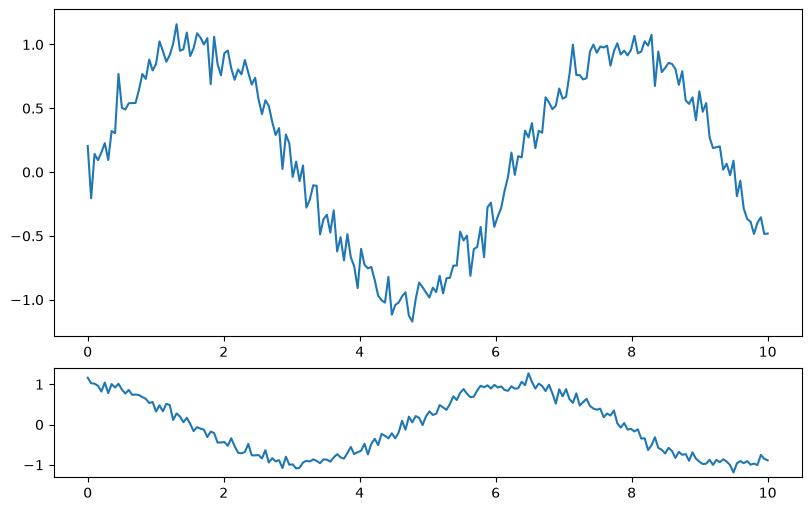

In [10]:
fig = plt.figure(figsize=(8, 5), layout="constrained")
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1])
fig.add_subplot(gs[0]).plot(t, signal1)
fig.add_subplot(gs[1]).plot(t, signal2)
plt.show()

**Experiment 3:** annotate with axes-relative coordinates.

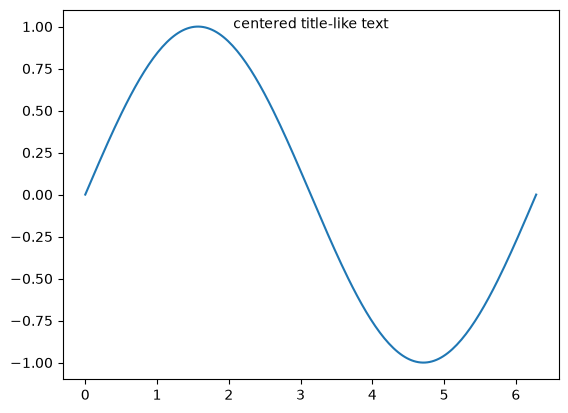

In [11]:
fig, ax = plt.subplots()
ax.plot(xs, np.sin(xs))
ax.text(0.5, 0.95, "centered title-like text", ha="center",
        transform=ax.transAxes)
plt.show()

**Experiment 4:** use a curved arrow style.

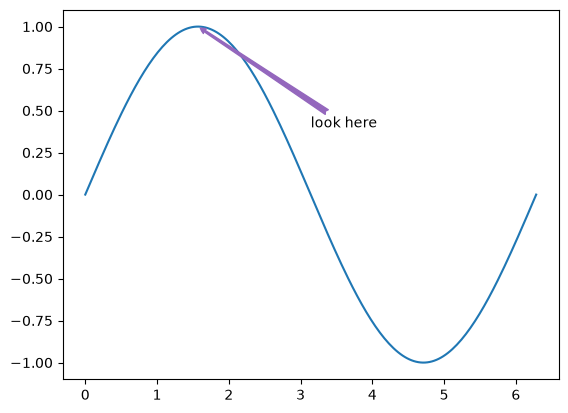

In [12]:
fig, ax = plt.subplots()
ax.plot(xs, np.sin(xs))
ax.annotate("look here", xy=(np.pi / 2, 1.0), xytext=(np.pi, 0.4),
            arrowprops=dict(arrowstyle="fancy", color="tab:purple"))
plt.show()

**Experiment 5:** a manual `subplots_adjust` as an alternative to tight layout.

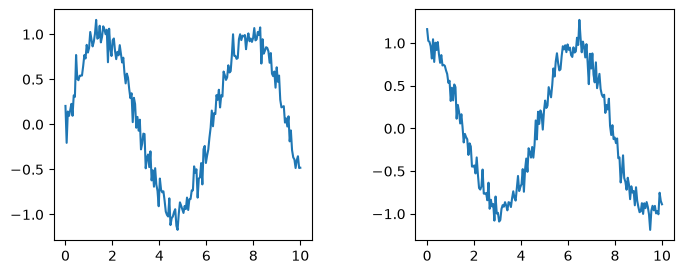

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(t, signal1)
axes[1].plot(t, signal2)
fig.subplots_adjust(wspace=0.4)
plt.show()

## 3. Mini Project — 2×2 Dashboard

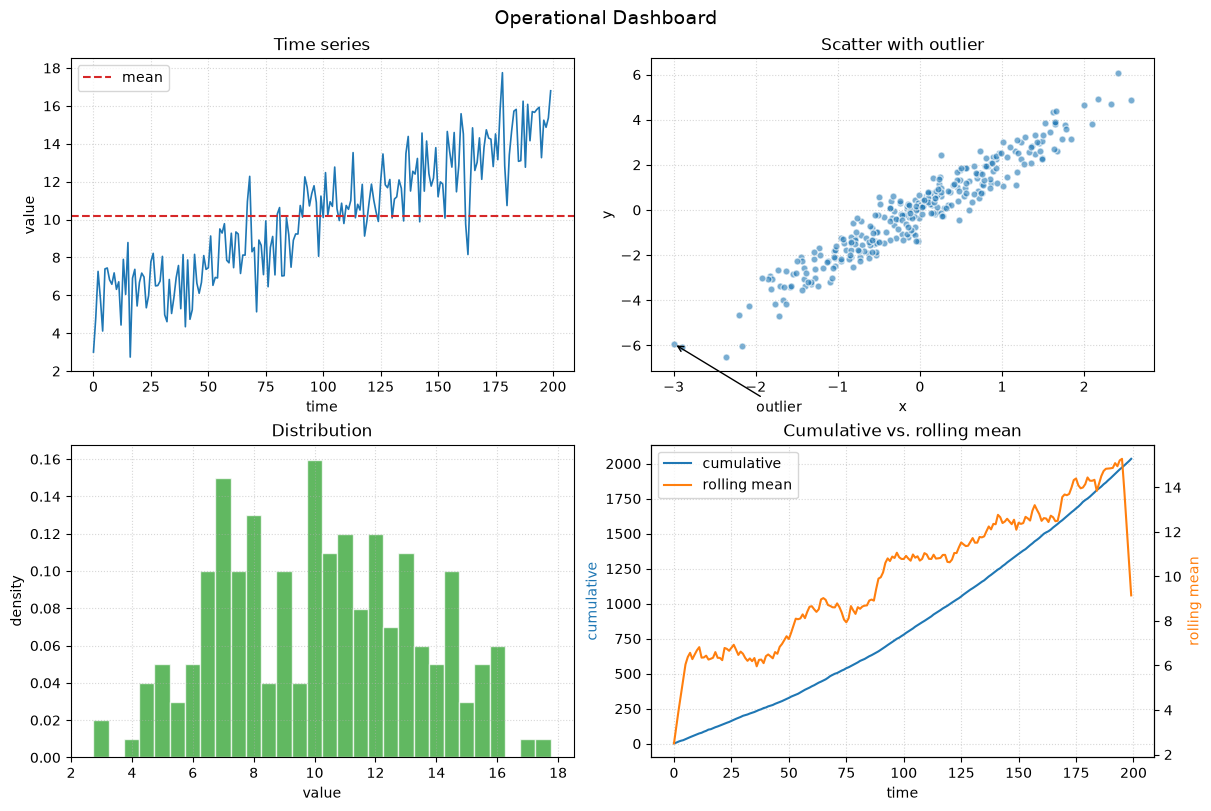

In [14]:
t = np.arange(200)
trend = 0.05 * t
series = trend + 5 + rng.normal(scale=1.5, size=t.size)

x_scatter = rng.normal(size=300)
y_scatter = 2 * x_scatter + rng.normal(scale=0.6, size=300)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")

# Top-left: time series with a mean reference line
ax = axes[0, 0]
ax.plot(t, series, color="tab:blue", linewidth=1.2)
ax.axhline(series.mean(), color="tab:red", linestyle="--", label="mean")
ax.set_title("Time series")
ax.set_xlabel("time")
ax.set_ylabel("value")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.5)

# Top-right: scatter with an annotated outlier
ax = axes[0, 1]
ax.scatter(x_scatter, y_scatter, s=25, alpha=0.6, edgecolors="white")
outlier_idx = int(np.argmax(np.abs(x_scatter)))
ax.annotate(
    "outlier",
    xy=(x_scatter[outlier_idx], y_scatter[outlier_idx]),
    xytext=(x_scatter[outlier_idx] + 1.0, y_scatter[outlier_idx] - 3.0),
    arrowprops=dict(arrowstyle="->", color="black"),
)
ax.set_title("Scatter with outlier")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, linestyle=":", alpha=0.5)

# Bottom-left: histogram of the time-series values
ax = axes[1, 0]
ax.hist(series, bins=30, density=True, color="tab:green", alpha=0.75,
        edgecolor="white")
ax.set_title("Distribution")
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.grid(True, linestyle=":", alpha=0.5)

# Bottom-right: cumulative sum on the left, rolling average on the right
ax = axes[1, 1]
ax2 = ax.twinx()
cumulative = np.cumsum(series)
window = 10
rolling = np.convolve(series, np.ones(window) / window, mode="same")

line1, = ax.plot(t, cumulative, color="tab:blue", label="cumulative")
ax.set_ylabel("cumulative", color="tab:blue")
line2, = ax2.plot(t, rolling, color="tab:orange", label="rolling mean")
ax2.set_ylabel("rolling mean", color="tab:orange")
ax.set_title("Cumulative vs. rolling mean")
ax.set_xlabel("time")
ax.legend(handles=[line1, line2], loc="upper left")
ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Operational Dashboard", fontsize=14)
fig.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()